In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

FL_BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"

os.makedirs(FL_BASE, exist_ok=True)
os.makedirs(os.path.join(FL_BASE, "fixed_seed_runs"), exist_ok=True)
os.makedirs(os.path.join(FL_BASE, "random_runs"), exist_ok=True)

os.makedirs("/content/tmp_fl_cm", exist_ok=True)

print("Federated Learning folders created successfully.")
print("Base folder:", FL_BASE)


Federated Learning folders created successfully.
Base folder: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi


In [ ]:
import pandas as pd

tradfi_path = "/content/drive/MyDrive/PhD_FraudDetection/data/tradfi/final_tradfi_preprocessed.csv"

df = pd.read_csv(tradfi_path)

df.head()


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,label
0,-1.732008,-0.940265,0.001987,2.076078,0.852117,-0.168304,0.333242,0.135717,0.015349,-0.007617,...,0.035991,0.592889,-0.145941,0.022471,-0.039443,-0.369729,0.261919,-0.074470,0.867279,0.0
1,-1.731922,1.049354,0.172414,-0.700960,0.325795,0.052775,-0.089103,-0.074200,0.003450,-0.448405,...,-0.258632,-0.838899,0.235842,-0.650344,0.050175,0.288299,-0.089827,0.030572,-0.785228,0.0
2,-1.731837,-0.939664,-0.717713,0.976089,0.282688,-0.251692,1.286188,0.554437,0.146986,-1.155078,...,0.404447,1.436798,1.778160,-1.172836,-1.067282,-0.260020,-0.199904,-0.188178,-1.365059,0.0
3,-1.731751,-0.766984,-0.056987,1.002312,-0.679172,0.011314,0.902878,0.134328,0.263390,-1.090536,...,-0.091012,0.148035,-0.287159,-1.841227,1.193220,-0.442725,0.084622,0.167664,-0.950746,0.0
4,-1.731665,-0.854295,0.458600,0.687404,0.297437,-0.203621,0.052391,0.396531,-0.300663,0.367064,...,0.048447,1.483438,-0.193822,0.155162,-0.798403,0.985284,0.483190,0.617645,0.332864,0.0


In [ ]:
!pip install -q xgboost reportlab matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.9 MB/s eta 0:00:00


In [ ]:
!pip install -q xgboost reportlab matplotlib seaborn


In [ ]:
# Federated deterministic run: LR, RF, XGB (seed = 42)
# Assumes df is already loaded and Drive is mounted.

import os, time, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

# ====== Config ======
SEED = 42
NUM_CLIENTS = 3
FED_ROUNDS = 5

FL_BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
os.makedirs(FL_BASE, exist_ok=True)
os.makedirs("/content/tmp_fl_cm", exist_ok=True)

# ====== Helpers ======
def stratified_split_for_clients(X, y, n_clients, seed=None):
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=seed)
    return [(X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True))
            for _, idx in skf.split(X, y)]

def evaluate_and_collect(y_true, y_prob, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }

def plot_cm(cm, title, path):
    plt.figure(figsize=(4,4))
    plt.imshow(np.array(cm), cmap="Blues")
    plt.title(title)
    plt.colorbar()
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i][j], ha='center', va='center', color="red")
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

# ===== FedAvg for Logistic Regression =====
def fedavg_logistic(clients_data, rounds=5, seed=None):
    n_features = clients_data[0][0].shape[1]
    global_coef = np.zeros(n_features)
    global_intercept = 0.0

    for _ in range(rounds):
        local_coefs, local_intercepts, sizes = [], [], []
        for (Xi, yi) in clients_data:
            model = SGDClassifier(loss="log", max_iter=1000, tol=1e-3, random_state=seed)
            model.fit(Xi, yi)
            local_coefs.append(model.coef_.ravel())
            local_intercepts.append(model.intercept_[0])
            sizes.append(len(yi))

        total = sum(sizes)
        global_coef = sum(c * s for c, s in zip(local_coefs, sizes)) / total
        global_intercept = sum(b * s for b, s in zip(local_intercepts, sizes)) / total

    class AvgModel:
        def predict(self, X):
            z = X.dot(global_coef) + global_intercept
            return (z > 0).astype(int)
        def predict_proba(self, X):
            z = X.dot(global_coef) + global_intercept
            p = 1 / (1 + np.exp(-z))
            return np.vstack([1-p, p]).T
    return AvgModel()

# ===== Server ensemble for RF / XGB =====
def server_ensemble_predict(models, Xtest, sizes):
    total = sum(sizes)
    probs = np.zeros((len(Xtest), 2))
    for m, s in zip(models, sizes):
        p = m.predict_proba(Xtest)
        probs += p * (s / total)
    y_prob = probs[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    return y_prob, y_pred

# ===== One FL Run =====
def run_fl(df, model_name, seed):
    np.random.seed(seed); random.seed(seed)
    X = df.drop("label", axis=1); y = df["label"]

    clients = stratified_split_for_clients(X, y, NUM_CLIENTS, seed)
    sizes = [len(ci[1]) for ci in clients]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        stratify=y, random_state=seed)

    # ----- LR -----
    if model_name == "lr":
        model = fedavg_logistic(clients, FED_ROUNDS, seed)
        y_prob = model.predict_proba(X_test)[:,1]
        y_pred = model.predict(X_test)

    # ----- RF / XGB -----
    else:
        models = []
        for (Xi, yi) in clients:
            if model_name == "rf":
                m = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                           random_state=seed)
            else:
                pos, neg = (yi==1).sum(), (yi==0).sum()
                spw = neg / pos if pos > 0 else 1.0
                m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                  eval_metric="logloss", random_state=seed,
                                  scale_pos_weight=spw)
            m.fit(Xi, yi)
            models.append(m)

        y_prob, y_pred = server_ensemble_predict(models, X_test, sizes)

    metrics = evaluate_and_collect(y_test, y_prob, y_pred)

    # Save outputs
    out_dir = os.path.join(FL_BASE, "fixed_seed_runs", model_name)
    os.makedirs(out_dir, exist_ok=True)

    json_path = os.path.join(out_dir, f"{model_name}_seed_42.json")
    with open(json_path, "w") as f:
        json.dump(metrics, f, indent=4)

    cm_path = f"/content/tmp_fl_cm/{model_name}_cm_seed42.png"
    plot_cm(metrics["confusion_matrix"], f"{model_name.upper()} FL Seed=42", cm_path)

    # PDF generation
    pdf_path = os.path.join(out_dir, f"{model_name}_seed42.pdf")
    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    styles = getSampleStyleSheet()
    story = []

    story.append(Paragraph(f"<b>Federated Learning — {model_name.upper()} — Seed 42</b>", styles["Title"]))
    story.append(Spacer(1,12))

    table_data = [["Metric", "Value"]] + [[k, f"{v:.4f}"] for k, v in metrics.items() if k != "confusion_matrix"]
    table = Table(table_data)
    table.setStyle(TableStyle([('GRID',(0,0),(-1,-1),0.5,colors.black)]))
    story.append(table)
    story.append(Spacer(1,12))
    story.append(Image(cm_path, width=400, height=300))

    doc.build(story)

    return metrics

# ===== RUN LR, RF, XGB =====
print("Running Federated Learning (Seed=42)...\n")

print("➡ Logistic Regression...")
lr_res = run_fl(df, "lr", SEED)
print(" LR:", lr_res, "\n")

print("➡ Random Forest...")
rf_res = run_fl(df, "rf", SEED)
print(" RF:", rf_res, "\n")

print("➡ XGBoost...")
xgb_res = run_fl(df, "xgb", SEED)
print(" XGB:", xgb_res, "\n")

print("All FL deterministic runs complete.")


Running Federated Learning (Seed=42)...

➡ Logistic Regression...


InvalidParameterError: The 'loss' parameter of SGDClassifier must be a str among {'huber', 'hinge', 'squared_epsilon_insensitive', 'squared_hinge', 'epsilon_insensitive', 'perceptron', 'squared_error', 'log_loss', 'modified_huber'}. Got 'log' instead.

In [ ]:
# Federated deterministic run: LR, RF, XGB (seed = 42)

import os, time, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

SEED = 42
NUM_CLIENTS = 3
FED_ROUNDS = 5

FL_BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
os.makedirs(FL_BASE, exist_ok=True)
os.makedirs("/content/tmp_fl_cm", exist_ok=True)

def stratified_split_for_clients(X, y, n_clients, seed=None):
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=seed)
    return [(X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True))
            for _, idx in skf.split(X, y)]

def evaluate_and_collect(y_true, y_prob, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }

def plot_cm(cm, title, path):
    plt.figure(figsize=(4,4))
    plt.imshow(np.array(cm), cmap="Blues")
    plt.title(title)
    plt.colorbar()
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i][j], ha='center', va='center', color="red")
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

# ===== CORRECTED FedAvg for Logistic Regression =====
def fedavg_logistic(clients_data, rounds=5, seed=None):
    n_features = clients_data[0][0].shape[1]
    global_coef = np.zeros(n_features)
    global_intercept = 0.0

    for _ in range(rounds):
        coefs, intercepts, sizes = [], [], []
        for (Xi, yi) in clients_data:
            model = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=seed)
            model.fit(Xi, yi)
            coefs.append(model.coef_.ravel())
            intercepts.append(model.intercept_[0])
            sizes.append(len(yi))

        total = sum(sizes)
        global_coef = sum(c * s for c, s in zip(coefs, sizes)) / total
        global_intercept = sum(b * s for b, s in zip(intercepts, sizes)) / total

    class AvgModel:
        def predict(self, X):
            z = X.dot(global_coef) + global_intercept
            return (z > 0).astype(int)
        def predict_proba(self, X):
            z = X.dot(global_coef) + global_intercept
            p = 1 / (1 + np.exp(-z))
            return np.vstack([1-p, p]).T

    return AvgModel()

def server_ensemble_predict(models, Xtest, sizes):
    total = sum(sizes)
    probs = np.zeros((len(Xtest), 2))
    for m, s in zip(models, sizes):
        p = m.predict_proba(Xtest)
        probs += p * (s / total)
    y_prob = probs[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    return y_prob, y_pred

def run_fl(df, model_name, seed):
    np.random.seed(seed); random.seed(seed)

    X = df.drop("label", axis=1); y = df["label"]
    clients = stratified_split_for_clients(X, y, NUM_CLIENTS, seed)
    sizes = [len(ci[1]) for ci in clients]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)

    if model_name == "lr":
        model = fedavg_logistic(clients, FED_ROUNDS, seed)
        y_prob = model.predict_proba(X_test)[:,1]
        y_pred = model.predict(X_test)
    else:
        models = []
        for (Xi, yi) in clients:
            if model_name == "rf":
                m = RandomForestClassifier(
                    n_estimators=200, class_weight="balanced", random_state=seed)
            else:
                pos, neg = (yi==1).sum(), (yi==0).sum()
                spw = neg / pos if pos > 0 else 1.0
                m = XGBClassifier(
                    n_estimators=300, max_depth=6, learning_rate=0.1,
                    eval_metric="logloss", random_state=seed, scale_pos_weight=spw)
            m.fit(Xi, yi)
            models.append(m)

        y_prob, y_pred = server_ensemble_predict(models, X_test, sizes)

    metrics = evaluate_and_collect(y_test, y_prob, y_pred)

    out_dir = os.path.join(FL_BASE, "fixed_seed_runs", model_name)
    os.makedirs(out_dir, exist_ok=True)

    json_path = os.path.join(out_dir, f"{model_name}_seed_42.json")
    with open(json_path, "w") as f:
        json.dump(metrics, f, indent=4)

    cm_path = f"/content/tmp_fl_cm/{model_name}_cm_seed42.png"
    plot_cm(metrics["confusion_matrix"], f"{model_name.upper()} FL Seed=42", cm_path)

    pdf_path = os.path.join(out_dir, f"{model_name}_seed42.pdf")
    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    styles = getSampleStyleSheet()
    story = []

    story.append(Paragraph(f"<b>Federated Learning — {model_name.upper()} — Seed 42</b>", styles["Title"]))
    story.append(Spacer(1,12))

    table_data = [["Metric","Value"]] + [
        [k, f"{v:.4f}"] for k,v in metrics.items() if k != "confusion_matrix"
    ]
    table = Table(table_data)
    table.setStyle(TableStyle([('GRID',(0,0),(-1,-1),0.5,colors.black)]))
    story.append(table)
    story.append(Spacer(1,12))
    story.append(Image(cm_path, width=400, height=300))

    doc.build(story)

    return metrics

# ==== RUN FL FOR ALL MODELS ====
print("Running FL seed=42...")

print("\n➡ LR...")
lr_res = run_fl(df, "lr", SEED)
print(lr_res)

print("\n➡ RF...")
rf_res = run_fl(df, "rf", SEED)
print(rf_res)

print("\n➡ XGB...")
xgb_res = run_fl(df, "xgb", SEED)
print(xgb_res)

print("\nAll done!")


Running FL seed=42...

➡ LR...


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


{'accuracy': 0.9976499690785405, 'precision': 0.5454545454545454, 'recall': 0.5714285714285714, 'f1': 0.5581395348837209, 'auc': np.float64(0.9979981575963719), 'confusion_matrix': [[8054, 10], [9, 12]]}

➡ RF...
{'accuracy': 0.9992578849721707, 'precision': 0.9411764705882353, 'recall': 0.7619047619047619, 'f1': 0.8421052631578947, 'auc': np.float64(0.9999468537414966), 'confusion_matrix': [[8063, 1], [5, 16]]}

➡ XGB...
{'accuracy': 0.9996289424860854, 'precision': 0.95, 'recall': 0.9047619047619048, 'f1': 0.926829268292683, 'auc': np.float64(0.9999527588813304), 'confusion_matrix': [[8063, 1], [2, 19]]}

All done!


In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
import os
import json

styles = getSampleStyleSheet()

output_pdf = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/FL_TradFi_Seed42_Combined.pdf"
doc = SimpleDocTemplate(output_pdf, pagesize=A4)
story = []

story.append(Paragraph("<b>Federated Learning — TradFi — Seed 42 — Combined Report</b>", styles["Title"]))
story.append(Spacer(1, 20))

model_names = ["lr", "rf", "xgb"]
model_labels = {"lr": "Logistic Regression", "rf": "Random Forest", "xgb": "XGBoost"}

for model in model_names:
    json_path = f"/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/{model}/{model}_seed_42.json"
    cm_path = f"/content/tmp_fl_cm/{model}_cm_seed42.png"

    with open(json_path, "r") as f:
        metrics = json.load(f)

    story.append(Paragraph(f"<b>{model_labels[model]}</b>", styles["Heading2"]))
    story.append(Spacer(1, 10))

    data = [
        ["Metric", "Value"],
        ["Accuracy", f"{metrics['accuracy']:.4f}"],
        ["Precision", f"{metrics['precision']:.4f}"],
        ["Recall", f"{metrics['recall']:.4f}"],
        ["F1 Score", f"{metrics['f1']:.4f}"],
        ["AUC", f"{metrics['auc']:.4f}"]
    ]

    table = Table(data)
    table.setStyle(TableStyle([
        ('GRID', (0,0), (-1,-1), 0.5, colors.black),
        ('BACKGROUND', (0,0), (-1,0), colors.lightgrey)
    ]))
    story.append(table)
    story.append(Spacer(1, 15))

    story.append(Paragraph("<b>Confusion Matrix</b>", styles["Heading3"]))
    story.append(Spacer(1, 8))
    story.append(Image(cm_path, width=400, height=300))
    story.append(Spacer(1, 25))

doc.build(story)

print("📄 Combined PDF generated successfully!")
print("Saved at:", output_pdf)


📄 Combined PDF generated successfully!
Saved at: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/FL_TradFi_Seed42_Combined.pdf


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/FL_TradFi_Seed42_Combined.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors

SEED_LIST = [0, 1, 7, 50, 123]
NUM_CLIENTS = 3
FED_ROUNDS = 5

FL_BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
os.makedirs(FL_BASE, exist_ok=True)
os.makedirs("/content/tmp_fl_cm", exist_ok=True)

def stratified_split_for_clients(X, y, n_clients, seed=None):
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=seed)
    return [(X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True))
            for _, idx in skf.split(X, y)]

def evaluate_and_collect(y_true, y_prob, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }

def plot_cm(cm, title, path):
    plt.figure(figsize=(4,4))
    plt.imshow(np.array(cm), cmap="Blues")
    plt.title(title)
    plt.colorbar()
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i][j], ha='center', va='center', color="red")
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

def fedavg_logistic(clients_data, rounds=5, seed=None):
    n = clients_data[0][0].shape[1]
    coef = np.zeros(n)
    intercept = 0.0

    for _ in range(rounds):
        local_coefs, local_intercepts, sizes = [], [], []
        for (Xi, yi) in clients_data:
            model = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=seed)
            model.fit(Xi, yi)
            local_coefs.append(model.coef_.ravel())
            local_intercepts.append(model.intercept_[0])
            sizes.append(len(yi))

        total = sum(sizes)
        coef = sum(c*s for c,s in zip(local_coefs, sizes)) / total
        intercept = sum(b*s for b,s in zip(local_intercepts, sizes)) / total

    class AvgModel:
        def predict(self, X):
            z = X.dot(coef) + intercept
            return (z > 0).astype(int)
        def predict_proba(self, X):
            z = X.dot(coef) + intercept
            p = 1/(1+np.exp(-z))
            return np.vstack([1-p, p]).T

    return AvgModel()

def server_ensemble_predict(models, Xtest, sizes):
    total = sum(sizes)
    probs = np.zeros((len(Xtest), 2))
    for m, s in zip(models, sizes):
        p = m.predict_proba(Xtest)
        probs += p * (s / total)
    y_prob = probs[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    return y_prob, y_pred

def run_fl(df, model_name, seed):
    np.random.seed(seed); random.seed(seed)

    X = df.drop("label", axis=1); y = df["label"]
    clients = stratified_split_for_clients(X, y, NUM_CLIENTS, seed)
    sizes = [len(ci[1]) for ci in clients]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)

    if model_name == "lr":
        model = fedavg_logistic(clients, FED_ROUNDS, seed)
        y_prob = model.predict_proba(X_test)[:,1]
        y_pred = model.predict(X_test)
    else:
        models = []
        for (Xi, yi) in clients:
            if model_name == "rf":
                m = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                           random_state=seed)
            else:
                pos, neg = (yi==1).sum(), (yi==0).sum()
                spw = neg / pos if pos>0 else 1.0
                m = XGBClassifier(
                    n_estimators=300, max_depth=6, learning_rate=0.1,
                    eval_metric="logloss", random_state=seed, scale_pos_weight=spw)
            m.fit(Xi, yi)
            models.append(m)

        y_prob, y_pred = server_ensemble_predict(models, X_test, sizes)

    metrics = evaluate_and_collect(y_test, y_prob, y_pred)

    out_dir = os.path.join(FL_BASE, "fixed_seed_runs", model_name)
    os.makedirs(out_dir, exist_ok=True)

    json_path = os.path.join(out_dir, f"{model_name}_seed_{seed}.json")
    with open(json_path, "w") as f:
        json.dump(metrics, f, indent=4)

    cm_path = f"/content/tmp_fl_cm/{model_name}_cm_seed_{seed}.png"
    plot_cm(metrics["confusion_matrix"], f"{model_name.upper()} FL Seed={seed}", cm_path)

    pdf_path = os.path.join(out_dir, f"{model_name}_seed_{seed}.pdf")
    styles = getSampleStyleSheet()
    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    story = []

    story.append(Paragraph(f"<b>Federated Learning — {model_name.upper()} — Seed {seed}</b>", styles["Title"]))
    story.append(Spacer(1,12))

    table_data = [["Metric","Value"]] + [
        [k, f"{v:.4f}"] for k,v in metrics.items() if k!="confusion_matrix"
    ]
    table = Table(table_data)
    table.setStyle(TableStyle([('GRID',(0,0),(-1,-1),0.5,colors.black)]))
    story.append(table)
    story.append(Spacer(1,12))
    story.append(Image(cm_path, width=400, height=300))

    doc.build(story)

    return metrics

# ===== RUN ALL FIXED SEEDS FOR ALL MODELS =====
models = ["lr", "rf", "xgb"]

print("🔥 Starting all fixed-seed FL runs...\n")

results_fixed = {}

for model in models:
    print(f"\n🚀 MODEL: {model.upper()}")
    results_fixed[model] = {}
    for seed in SEED_LIST:
        print(f"  → Running seed {seed} ...")
        metrics = run_fl(df, model, seed)
        results_fixed[model][seed] = metrics
        print(f"    Done. Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")

print("\n🎉 All fixed seed FL runs completed!")


🔥 Starting all fixed-seed FL runs...


🚀 MODEL: LR
  → Running seed 0 ...
    Done. Acc=0.9981, F1=0.6154
  → Running seed 1 ...
    Done. Acc=0.9983, F1=0.6111
  → Running seed 7 ...
    Done. Acc=0.9981, F1=0.4828
  → Running seed 50 ...
    Done. Acc=0.9985, F1=0.6667
  → Running seed 123 ...
    Done. Acc=0.9986, F1=0.7027

🚀 MODEL: RF
  → Running seed 0 ...
    Done. Acc=0.9990, F1=0.7778
  → Running seed 1 ...
    Done. Acc=0.9991, F1=0.8108
  → Running seed 7 ...
    Done. Acc=0.9991, F1=0.8108
  → Running seed 50 ...
    Done. Acc=0.9994, F1=0.8649
  → Running seed 123 ...
    Done. Acc=0.9996, F1=0.9231

🚀 MODEL: XGB
  → Running seed 0 ...
    Done. Acc=0.9993, F1=0.8500
  → Running seed 1 ...
    Done. Acc=0.9994, F1=0.8780
  → Running seed 7 ...
    Done. Acc=0.9995, F1=0.9000
  → Running seed 50 ...
    Done. Acc=0.9994, F1=0.8718
  → Running seed 123 ...
    Done. Acc=0.9996, F1=0.9268

🎉 All fixed seed FL runs completed!


,model,model_name,seed,accuracy,precision,recall,f1,auc
0,lr,Logistic Regression,0,0.998145,0.666667,0.571429,0.615385,0.998435
1,lr,Logistic Regression,1,0.998268,0.733333,0.523810,0.611111,0.998559
2,lr,Logistic Regression,7,0.998145,0.875000,0.333333,0.482759,0.981228
3,lr,Logistic Regression,42,0.997650,0.545455,0.571429,0.558140,0.997998
4,lr,Logistic Regression,50,0.998516,0.800000,0.571429,0.666667,0.988792
5,lr,Logistic Regression,123,0.998639,0.812500,0.619048,0.702703,0.998683
6,rf,Random Forest,0,0.999011,0.933333,0.666667,0.777778,0.999923
7,rf,Random Forest,1,0.999134,0.937500,0.714286,0.810811,0.999923
8,rf,Random Forest,7,0.999134,0.937500,0.714286,0.810811,0.999935
9,rf,Random Forest,42,0.999258,0.941176,0.761905,0.842105,0.999947


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std,f1_rel_std_percent,stability
0,lr,0.998227,0.000347,0.738826,0.118611,0.531746,0.101761,0.606127,0.078262,0.993949,0.007330,12.911816,Unstable
1,rf,0.999258,0.000221,0.958252,0.032433,0.746032,0.065060,0.838241,0.051150,0.999944,0.000021,6.102064,Unstable
2,xgb,0.999464,0.000150,0.931092,0.026255,0.857143,0.042592,0.892250,0.031166,0.999955,0.000023,3.492967,Unstable


Saved master CSV: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/summaries/FL_fixed_seed_master_table_per_seed.csv
Saved aggregated CSV: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/summaries/FL_fixed_seed_agg_mean_std.csv


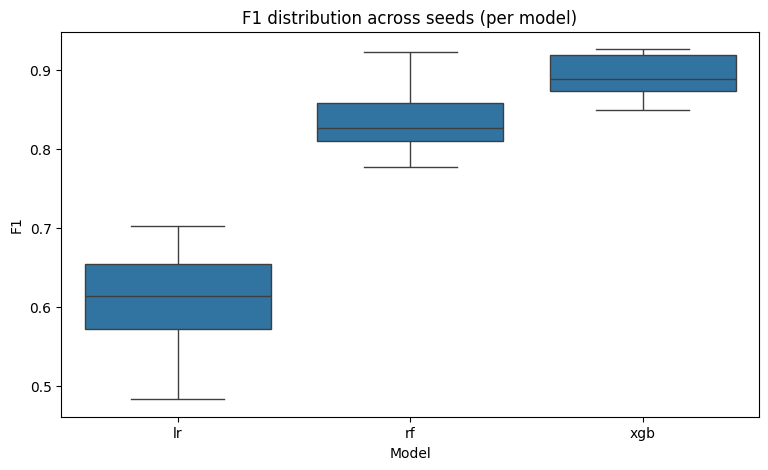

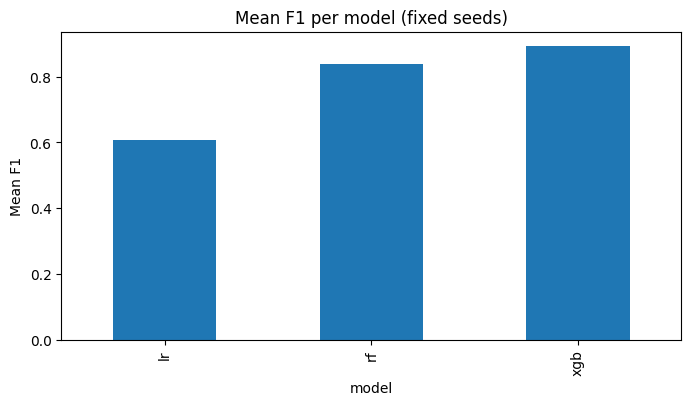

Combined PDF built: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/summaries/FL_TradFi_FixedSeeds_Combined_Report.pdf
Zipped individual PDFs to: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/summaries/FL_fixed_seed_individual_pdfs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Combined PDF and (optional) zip download triggered.


In [ ]:
# Aggregator: Build Master Summary + Stability + Combined PDF for FL fixed-seed runs
# Run this in Colab (after you ran all seeds)

!pip install -q reportlab matplotlib seaborn

import os, glob, json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from google.colab import files

# -----------------------
# Config / paths
# -----------------------
FL_BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
FIXED_BASE = os.path.join(FL_BASE, "fixed_seed_runs")
TMP_CM = "/content/tmp_fl_cm"
OUTPUT_FOLDER = os.path.join(FL_BASE, "summaries")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
COMBINED_PDF = os.path.join(OUTPUT_FOLDER, "FL_TradFi_FixedSeeds_Combined_Report.pdf")
ZIP_OUT = os.path.join(OUTPUT_FOLDER, "FL_fixed_seed_individual_pdfs.zip")

models = ["lr", "rf", "xgb"]
model_names = {"lr":"Logistic Regression", "rf":"Random Forest", "xgb":"XGBoost"}

# -----------------------
# Load JSON results
# -----------------------
rows = []
cms = {}  # map (model, seed) -> cm path if exists

for model in models:
    folder = os.path.join(FIXED_BASE, model)
    if not os.path.isdir(folder):
        print(f"WARNING: folder not found for {model}: {folder}")
        continue
    files_json = sorted(glob.glob(os.path.join(folder, "*.json")))
    if len(files_json) == 0:
        print(f"WARNING: no json files found in {folder}")
    for jf in files_json:
        try:
            with open(jf, "r") as f:
                j = json.load(f)
            # attempt to read seed from filename or field
            fname = os.path.basename(jf)
            # seed guessing
            seed = None
            if "seed_" in fname:
                try:
                    seed = int(fname.split("seed_")[-1].split(".json")[0])
                except:
                    seed = j.get("seed_or_run", j.get("seed", None))
            else:
                seed = j.get("seed_or_run", j.get("seed", None))
            # metrics may be stored as raw dict or under 'metrics'
            metrics = j if set(["accuracy","precision","recall","f1","auc"]).issubset(set(j.keys())) else j.get("metrics", {})
            row = {
                "model": model,
                "model_name": model_names.get(model, model),
                "seed": seed,
                "accuracy": float(metrics.get("accuracy", np.nan)),
                "precision": float(metrics.get("precision", np.nan)),
                "recall": float(metrics.get("recall", np.nan)),
                "f1": float(metrics.get("f1", np.nan)),
                "auc": float(metrics.get("auc", np.nan))
            }
            rows.append(row)
            # store cm path if exists (naming conventions used earlier)
            cm_candidate = os.path.join(TMP_CM, f"{model}_cm_seed_{seed}.png")
            cm_candidate2 = os.path.join(TMP_CM, f"{model}_cm_seed{seed}.png")
            cm_candidate3 = os.path.join(TMP_CM, f"{model}_cm_seed{seed}.png")
            if os.path.exists(cm_candidate):
                cms[(model, seed)] = cm_candidate
            elif os.path.exists(cm_candidate2):
                cms[(model, seed)] = cm_candidate2
            elif os.path.exists(cm_candidate3):
                cms[(model, seed)] = cm_candidate3
            else:
                # maybe cm was saved with other naming; try pattern
                alt = glob.glob(os.path.join(TMP_CM, f"{model}*{seed}*.png"))
                if alt:
                    cms[(model, seed)] = alt[0]
        except Exception as e:
            print("Failed to read", jf, ":", e)

# Build dataframe
df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No results loaded — check the fixed_seed_runs folders and JSON files.")

# Display Master summary table (per-seed)
display(df.sort_values(["model","seed"]).reset_index(drop=True))

# -----------------------
# Per-model mean ± std and stability (rel_std on F1)
# -----------------------
agg = df.groupby("model").agg({
    "accuracy":["mean","std"],
    "precision":["mean","std"],
    "recall":["mean","std"],
    "f1":["mean","std"],
    "auc":["mean","std"]
}).round(6)

# flatten columns
agg.columns = ["_".join(col).strip() for col in agg.columns.values]
agg = agg.reset_index()
# compute rel_std %
agg["f1_rel_std_percent"] = (agg["f1_std"] / agg["f1_mean"]) * 100
agg["stability"] = agg["f1_rel_std_percent"].apply(lambda v: "Stable" if (not np.isnan(v) and v<=3.0) else ("Unstable" if not np.isnan(v) else "NA"))

display(agg)

# Save CSVs
master_csv = os.path.join(OUTPUT_FOLDER, "FL_fixed_seed_master_table_per_seed.csv")
agg_csv = os.path.join(OUTPUT_FOLDER, "FL_fixed_seed_agg_mean_std.csv")
df.to_csv(master_csv, index=False)
agg.to_csv(agg_csv, index=False)
print("Saved master CSV:", master_csv)
print("Saved aggregated CSV:", agg_csv)

# -----------------------
# Plots: F1 boxplot and mean-F1 barplot
# -----------------------
plt.figure(figsize=(9,5))
sns.boxplot(x="model", y="f1", data=df, order=models)
plt.title("F1 distribution across seeds (per model)")
plt.xlabel("Model")
plt.ylabel("F1")
boxplot_path = os.path.join(OUTPUT_FOLDER, "f1_boxplot_fixed_seeds.png")
plt.savefig(boxplot_path, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8,4))
mean_f1 = df.groupby("model")["f1"].mean().reindex(models)
mean_f1.plot(kind="bar")
plt.ylabel("Mean F1")
plt.title("Mean F1 per model (fixed seeds)")
barplot_path = os.path.join(OUTPUT_FOLDER, "mean_f1_fixed_seeds.png")
plt.savefig(barplot_path, bbox_inches="tight")
plt.close()

# show small preview in notebook
from IPython.display import Image as IPyImage, display as ipydisplay
ipydisplay(IPyImage(boxplot_path, width=700))
ipydisplay(IPyImage(barplot_path, width=500))

# -----------------------
# Build Combined PDF
# -----------------------
styles = getSampleStyleSheet()
doc = SimpleDocTemplate(COMBINED_PDF, pagesize=A4)
story = []

story.append(Paragraph("<b>Federated Learning — TradFi — Fixed Seeds (Combined Report)</b>", styles['Title']))
story.append(Spacer(1,12))
story.append(Paragraph("This report summarizes FL experiments (fixed seeds) across LR, RF and XGB.", styles['BodyText']))
story.append(Spacer(1,12))

# Add aggregated table (mean ± std)
story.append(Paragraph("<b>Aggregated Mean ± Std (per model)</b>", styles['Heading2']))
story.append(Spacer(1,8))
# prepare table data
agg_table = [["Model", "F1 mean", "F1 std", "F1 rel_std (%)", "Stability"]]
for _, r in agg.iterrows():
    agg_table.append([r["model"], f"{r['f1_mean']:.4f}", f"{r['f1_std']:.4f}", f"{r['f1_rel_std_percent']:.2f}", r["stability"]])
t = Table(agg_table, hAlign='LEFT')
t.setStyle(TableStyle([('GRID',(0,0),(-1,-1),0.4,colors.black),('BACKGROUND',(0,0),(-1,0),colors.lightgrey)]))
story.append(t)
story.append(PageBreak())

# Add F1 boxplot and mean barplot
story.append(Paragraph("<b>F1 Distribution (boxplot)</b>", styles['Heading2']))
story.append(Spacer(1,8))
story.append(Image(boxplot_path, width=450, height=300))
story.append(PageBreak())

story.append(Paragraph("<b>Mean F1 per Model</b>", styles['Heading2']))
story.append(Spacer(1,8))
story.append(Image(barplot_path, width=450, height=250))
story.append(PageBreak())

# Add per-model details + confusion matrices for each seed
for model in models:
    story.append(Paragraph(f"<b>{model_names.get(model,model)}</b>", styles['Heading2']))
    story.append(Spacer(1,8))
    subdf = df[df['model']==model].sort_values("seed")
    # per-seed metrics table
    table_data = [["Seed","Accuracy","Precision","Recall","F1","AUC"]]
    for _, row in subdf.iterrows():
        table_data.append([str(int(row['seed']) if not pd.isna(row['seed']) else "NA"),
                           f"{row['accuracy']:.4f}", f"{row['precision']:.4f}", f"{row['recall']:.4f}", f"{row['f1']:.4f}", f"{row['auc']:.4f}"])
    story.append(Table(table_data, hAlign='LEFT'))
    story.append(Spacer(1,8))
    # add confusion matrices, one per seed on its own page
    for _, row in subdf.iterrows():
        seed = row['seed']
        cm_path = cms.get((model, seed), None)
        if cm_path and os.path.exists(cm_path):
            story.append(Paragraph(f"<b>Confusion Matrix — seed {seed}</b>", styles['Heading3']))
            story.append(Spacer(1,6))
            story.append(Image(cm_path, width=420, height=320))
            story.append(PageBreak())
    # if no CMs found for this model, add notice
    if not any((model, s) in cms for s in subdf['seed']):
        story.append(Paragraph("No confusion-matrix images found for this model in tmp folder.", styles['BodyText']))
        story.append(PageBreak())

# Build PDF
doc.build(story)
print("Combined PDF built:", COMBINED_PDF)

# -----------------------
# Zip all individual per-run PDFs (optional) and download
# -----------------------
# collect individual pdfs
pdf_paths = []
for model in models:
    folder = os.path.join(FIXED_BASE, model)
    pdf_paths += glob.glob(os.path.join(folder, "*.pdf"))

if pdf_paths:
    with zipfile.ZipFile(ZIP_OUT, 'w') as zf:
        for p in pdf_paths:
            zf.write(p, arcname=os.path.basename(p))
    print("Zipped individual PDFs to:", ZIP_OUT)
    files.download(ZIP_OUT)
else:
    print("No individual per-run PDFs found to zip.")

# Download combined PDF
files.download(COMBINED_PDF)
print("Done. Combined PDF and (optional) zip download triggered.")


In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
import os, json, glob
import pandas as pd

FL_BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
FIXED_BASE = os.path.join(FL_BASE, "fixed_seed_runs")
TMP_CM = "/content/tmp_fl_cm"
OUTPUT_DIR = os.path.join(FL_BASE, "modelwise_summaries")
os.makedirs(OUTPUT_DIR, exist_ok=True)

models = {
    "lr": "Logistic Regression",
    "rf": "Random Forest",
    "xgb": "XGBoost"
}

SEED_LIST = [0, 1, 7, 50, 123]
styles = getSampleStyleSheet()

def load_results(model):
    results = []
    model_folder = os.path.join(FIXED_BASE, model)
    for seed in SEED_LIST:
        json_path = os.path.join(model_folder, f"{model}_seed_{seed}.json")
        if not os.path.exists(json_path):
            print(f"Missing JSON for model={model}, seed={seed}")
            continue
        with open(json_path, "r") as f:
            metrics = json.load(f)
        results.append({
            "seed": seed,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "auc": metrics["auc"],
            "cm": metrics["confusion_matrix"]
        })
    return results

def generate_pdf(model, model_label):
    pdf_path = os.path.join(OUTPUT_DIR, f"{model_label.replace(' ','_')}_FixedSeeds_Report.pdf")
    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    story = []

    story.append(Paragraph(f"<b>{model_label} — Federated Learning Fixed Seed Results</b>", styles['Title']))
    story.append(Spacer(1, 20))

    results = load_results(model)

    # ---- Seed-wise Metrics Table ----
    story.append(Paragraph("<b>Seed-wise Metrics</b>", styles["Heading2"]))
    story.append(Spacer(1, 10))

    table_data = [["Seed", "Accuracy", "Precision", "Recall", "F1", "AUC"]]
    for r in results:
        table_data.append([
            r["seed"],
            f"{r['accuracy']:.4f}",
            f"{r['precision']:.4f}",
            f"{r['recall']:.4f}",
            f"{r['f1']:.4f}",
            f"{r['auc']:.4f}"
        ])

    table = Table(table_data)
    table.setStyle(TableStyle([
        ("GRID", (0,0), (-1,-1), 0.5, colors.black),
        ("BACKGROUND", (0,0), (-1,0), colors.lightgrey)
    ]))
    story.append(table)
    story.append(PageBreak())

    # ---- Confusion Matrices Per Seed ----
    for r in results:
        cm = r["cm"]
        seed = r["seed"]

        story.append(Paragraph(f"<b>Confusion Matrix — Seed {seed}</b>", styles["Heading2"]))
        story.append(Spacer(1, 10))

        # Save temporary image
        import matplotlib.pyplot as plt
        import numpy as np

        cm_img = f"/content/tmp_fl_cm/{model}_summary_seed_{seed}.png"
        plt.figure(figsize=(3,3))
        plt.imshow(np.array(cm), cmap="Blues")
        plt.title(f"{model_label} - Seed {seed}")
        plt.colorbar()
        for i in range(len(cm)):
            for j in range(len(cm[0])):
                plt.text(j, i, cm[i][j], ha='center', va='center', color="red")
        plt.tight_layout()
        plt.savefig(cm_img)
        plt.close()

        story.append(Image(cm_img, width=350, height=300))
        story.append(PageBreak())

    doc.build(story)
    print(f"Generated PDF: {pdf_path}")

# --- Generate PDFs for all models ---
for m, name in models.items():
    generate_pdf(m, name)


Generated PDF: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_summaries/Logistic_Regression_FixedSeeds_Report.pdf
Generated PDF: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_summaries/Random_Forest_FixedSeeds_Report.pdf
Generated PDF: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_summaries/XGBoost_FixedSeeds_Report.pdf


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_summaries/Logistic_Regression_FixedSeeds_Report.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
import os, json
import matplotlib.pyplot as plt
import numpy as np

# Paths
FL_BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
FIXED_BASE = os.path.join(FL_BASE, "fixed_seed_runs")
OUTPUT_DIR = os.path.join(FL_BASE, "modelwise_summaries_corrected")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED_LIST = [0, 1, 7, 50, 123]

models = {
    "lr": "Logistic Regression",
    "rf": "Random Forest",
    "xgb": "XGBoost"
}

styles = getSampleStyleSheet()

# Function to load JSON results per model
def load_seed_results(model):
    results = []
    for seed in SEED_LIST:
        json_path = f"{FIXED_BASE}/{model}/{model}_seed_{seed}.json"
        if not os.path.exists(json_path):
            print(f"Missing JSON for {model}_seed_{seed}")
            continue

        with open(json_path, "r") as f:
            met = json.load(f)

        results.append({
            "seed": seed,
            "accuracy": met["accuracy"],
            "precision": met["precision"],
            "recall": met["recall"],
            "f1": met["f1"],
            "auc": met["auc"],
            "cm": met["confusion_matrix"]
        })
    return results


def generate_model_pdf(model, model_label):
    pdf_path = os.path.join(OUTPUT_DIR, f"{model_label.replace(' ','_')}_FixedSeed_Report.pdf")
    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    story = []

    story.append(Paragraph(f"<b>{model_label} — Federated Learning Fixed-Seed Report</b>", styles["Title"]))
    story.append(Spacer(1,20))

    results = load_seed_results(model)

    for r in results:
        seed = r["seed"]
        cm = r["cm"]

        # ---- Seed Title ----
        story.append(Paragraph(f"<b>Seed {seed}</b>", styles["Heading2"]))
        story.append(Spacer(1,10))

        # ---- Metrics Table ----
        table_data = [
            ["Metric", "Value"],
            ["Accuracy", f"{r['accuracy']:.4f}"],
            ["Precision", f"{r['precision']:.4f}"],
            ["Recall", f"{r['recall']:.4f}"],
            ["F1 Score", f"{r['f1']:.4f}"],
            ["AUC", f"{r['auc']:.4f}"]
        ]

        table = Table(table_data)
        table.setStyle(TableStyle([
            ("GRID", (0,0), (-1,-1), 0.5, colors.black),
            ("BACKGROUND", (0,0), (-1,0), colors.lightgrey)
        ]))

        story.append(table)
        story.append(Spacer(1,12))

        # ---- Confusion Matrix Image ----
        cm_img = f"/content/tmp_fl_cm/{model}_summary_cm_seed_{seed}.png"
        plt.figure(figsize=(3,3))
        plt.imshow(np.array(cm), cmap="Blues")
        plt.title(f"{model_label} - Seed {seed}")
        plt.colorbar()
        for i in range(len(cm)):
            for j in range(len(cm[0])):
                plt.text(j, i, cm[i][j], ha='center', va='center', color="red")
        plt.tight_layout()
        plt.savefig(cm_img)
        plt.close()

        story.append(Paragraph("<b>Confusion Matrix</b>", styles["Heading3"]))
        story.append(Spacer(1,6))
        story.append(Image(cm_img, width=350, height=300))
        story.append(PageBreak())

    doc.build(story)
    print("Generated PDF:", pdf_path)


# Generate PDFs for LR, RF, XGB
for m, name in models.items():
    generate_model_pdf(m, name)


Generated PDF: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_summaries_corrected/Logistic_Regression_FixedSeed_Report.pdf
Generated PDF: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_summaries_corrected/Random_Forest_FixedSeed_Report.pdf
Generated PDF: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_summaries_corrected/XGBoost_FixedSeed_Report.pdf


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_summaries_corrected/Logistic_Regression_FixedSeed_Report.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import glob

print("LR JSONs:", glob.glob("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/*.json"))
print("RF JSONs:", glob.glob("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/rf/*.json"))
print("XGB JSONs:", glob.glob("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/xgb/*.json"))


LR JSONs: ['/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_42.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_0.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_1.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_7.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_50.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_123.json']
RF JSONs: ['/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/rf/rf_seed_42.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/rf/rf_seed_0.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/rf/rf_seed_1.json', '

In [ ]:
import glob

print("LR JSONs:", glob.glob("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/*.json"))
print("RF JSONs:", glob.glob("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/rf/*.json"))
print("XGB JSONs:", glob.glob("/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/xgb/*.json"))


LR JSONs: ['/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_42.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_0.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_1.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_7.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_50.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/lr/lr_seed_123.json']
RF JSONs: ['/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/rf/rf_seed_42.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/rf/rf_seed_0.json', '/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/fixed_seed_runs/rf/rf_seed_1.json', '

In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
import os, json
import matplotlib.pyplot as plt
import numpy as np

# Paths
BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
FIXED = f"{BASE}/fixed_seed_runs"
OUTPUT = f"{BASE}/modelwise_seed_RF_XGB"
os.makedirs(OUTPUT, exist_ok=True)

SEEDS = [0, 1, 7, 50, 123, 42]

models = {
    "rf": "Random Forest",
    "xgb": "XGBoost"
}

styles = getSampleStyleSheet()


# ----------- Load metrics per model -----------
def load_results(model):
    results = []
    for seed in SEEDS:
        json_path = f"{FIXED}/{model}/{model}_seed_{seed}.json"

        if not os.path.exists(json_path):
            continue

        with open(json_path, "r") as f:
            m = json.load(f)

        results.append({
            "seed": seed,
            "accuracy": m["accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "auc": m["auc"],
            "cm": m["confusion_matrix"]
        })
    return results


# ----------- PDF generator -----------
def make_pdf(model, label):
    pdf_path = f"{OUTPUT}/{label.replace(' ','_')}_FixedSeeds_Report.pdf"
    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    story = []

    story.append(Paragraph(f"<b>{label} — Federated Learning Fixed Seed Report</b>", styles["Title"]))
    story.append(Spacer(1, 20))

    results = load_results(model)

    for r in results:
        seed = r["seed"]
        cm = r["cm"]

        # Seed title
        story.append(Paragraph(f"<b>Seed {seed}</b>", styles["Heading2"]))
        story.append(Spacer(1, 10))

        # Metrics Table
        tdata = [
            ["Metric", "Value"],
            ["Accuracy", f"{r['accuracy']:.4f}"],
            ["Precision", f"{r['precision']:.4f}"],
            ["Recall", f"{r['recall']:.4f}"],
            ["F1 Score", f"{r['f1']:.4f}"],
            ["AUC", f"{r['auc']:.4f}"]
        ]

        table = Table(tdata)
        table.setStyle(TableStyle([
            ("GRID", (0,0), (-1,-1), 0.6, colors.black),
            ("BACKGROUND", (0,0), (-1,0), colors.lightgrey)
        ]))

        story.append(table)
        story.append(Spacer(1, 12))

        # Confusion Matrix
        cm_img = f"/content/tmp_fl_cm/{model}_summary_seed_{seed}.png"

        plt.figure(figsize=(3,3))
        plt.imshow(np.array(cm), cmap="Blues")
        plt.title(f"{label} - Seed {seed}")
        plt.colorbar()
        for i in range(len(cm)):
            for j in range(len(cm[0])):
                plt.text(j, i, cm[i][j], ha="center", va="center", color="red")
        plt.tight_layout()
        plt.savefig(cm_img)
        plt.close()

        story.append(Paragraph("<b>Confusion Matrix</b>", styles["Heading3"]))
        story.append(Image(cm_img, width=350, height=300))
        story.append(PageBreak())

    doc.build(story)
    print("Generated PDF:", pdf_path)


# Generate only RF and XGB PDFs
make_pdf("rf", "Random Forest")
make_pdf("xgb", "XGBoost")


Generated PDF: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_seed_RF_XGB/Random_Forest_FixedSeeds_Report.pdf
Generated PDF: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/modelwise_seed_RF_XGB/XGBoost_FixedSeeds_Report.pdf


In [ ]:
# FULL AUTOMATIC: FL Random Runs (no seed) for LR, RF, XGB -> 5 runs each
# Saves JSONs: lr_random_1.json ... rf_random_5.json etc. in R1 folder
# Produces 3 model-wise PDFs (one per model) and triggers downloads.

!pip install -q xgboost reportlab matplotlib seaborn

import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from google.colab import files

# ---------- CONFIG ----------
BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
RANDOM_BASE = os.path.join(BASE, "random_runs")
os.makedirs(RANDOM_BASE, exist_ok=True)
for m in ["lr","rf","xgb"]:
    os.makedirs(os.path.join(RANDOM_BASE, m), exist_ok=True)

TMP_CM = "/content/tmp_fl_cm"
os.makedirs(TMP_CM, exist_ok=True)

NUM_CLIENTS = 3
FED_ROUNDS = 5
RUNS = 5  # number of random runs per model

SEED_LIST = None  # no seed for random runs

# ensure df exists in notebook
try:
    df
except NameError:
    # adjust path if different
    df_path = "/content/drive/MyDrive/PhD_FraudDetection/data/tradfi/final_tradfi_preprocessed.csv"
    df = pd.read_csv(df_path)

# ---------- Helper functions ----------
def stratified_split_for_clients(X, y, n_clients, seed=None):
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=seed)
    parts = []
    for _, idx in skf.split(X, y):
        parts.append((X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)))
    return parts

def evaluate_and_collect(y_true, y_prob, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_pred)
    return {"accuracy": float(acc), "precision": float(prec), "recall": float(rec), "f1": float(f1), "auc": float(auc), "confusion_matrix": cm.tolist()}

def plot_and_save_cm(cm, title, path):
    plt.figure(figsize=(4,4))
    plt.imshow(np.array(cm), cmap="Blues")
    plt.title(title)
    plt.colorbar()
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i][j], ha='center', va='center', color="red")
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

# FedAvg logistic (averaging local linear models)
def fedavg_logistic(clients_data, rounds=5):
    n_features = clients_data[0][0].shape[1]
    global_coef = np.zeros(n_features)
    global_intercept = 0.0
    for _ in range(rounds):
        local_coefs = []
        local_intercepts = []
        local_sizes = []
        for Xi, yi in clients_data:
            model = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3)
            model.fit(Xi, yi)
            local_coefs.append(model.coef_.ravel())
            local_intercepts.append(model.intercept_.ravel()[0])
            local_sizes.append(len(yi))
        total = sum(local_sizes)
        global_coef = sum(c * s for c, s in zip(local_coefs, local_sizes)) / total
        global_intercept = sum(b * s for b, s in zip(local_intercepts, local_sizes)) / total
    class AvgLogistic:
        def predict(self, X):
            z = X.dot(global_coef) + global_intercept
            return (z > 0).astype(int)
        def predict_proba(self, X):
            z = X.dot(global_coef) + global_intercept
            p = 1 / (1 + np.exp(-z))
            return np.vstack([1-p, p]).T
    return AvgLogistic()

def server_ensemble_predict(clients_models, X_test, client_sizes):
    total = sum(client_sizes)
    probs = np.zeros((len(X_test), 2))
    for model, size in zip(clients_models, client_sizes):
        try:
            p = model.predict_proba(X_test)
        except:
            df_dec = model.decision_function(X_test)
            p1 = 1 / (1 + np.exp(-df_dec))
            p = np.vstack([1-p1, p1]).T
        probs += p * (size / total)
    y_prob = probs[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    return y_prob, y_pred

# ---------- Single random (no-seed) run for a given model ----------
def run_random_once(df, model_name, run_idx):
    # no seed: true randomness
    X = df.drop("label", axis=1); y = df["label"]
    clients = stratified_split_for_clients(X, y, NUM_CLIENTS, seed=None)
    client_sizes = [len(c[1]) for c in clients]
    # central test split (random)
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
    if model_name == "lr":
        global_model = fedavg_logistic(clients, rounds=FED_ROUNDS)
        y_prob = global_model.predict_proba(X_test)[:,1]
        y_pred = global_model.predict(X_test)
    else:
        clients_models = []
        for Xi, yi in clients:
            if model_name == "rf":
                m = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1)
            else: # xgb
                pos = (yi==1).sum(); neg = (yi==0).sum()
                spw = float(neg/pos) if pos>0 else 1.0
                m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=spw, n_jobs=-1)
            m.fit(Xi, yi)
            clients_models.append(m)
        y_prob, y_pred = server_ensemble_predict(clients_models, X_test, client_sizes)
    metrics = evaluate_and_collect(y_test, y_prob, y_pred)
    # Save JSON & CM & PDF per run
    folder = os.path.join(RANDOM_BASE, model_name)
    os.makedirs(folder, exist_ok=True)
    json_name = f"{model_name}_random_{run_idx}.json"
    json_path = os.path.join(folder, json_name)
    with open(json_path, "w") as f:
        json.dump(metrics, f, indent=4)
    cm_path = os.path.join(TMP_CM, f"{model_name}_cm_random_{run_idx}.png")
    plot_and_save_cm(metrics["confusion_matrix"], f"{model_name.upper()} run {run_idx}", cm_path)
    return {"metrics": metrics, "json_path": json_path, "cm_path": cm_path}

# ---------- Run all random runs for all models ----------
models = ["lr", "rf", "xgb"]
all_results = {m: {} for m in models}
print("Starting random (no-seed) FL runs: 5 runs per model ...")
for m in models:
    print(f"\n=== MODEL: {m.upper()} ===")
    for i in range(1, RUNS+1):
        print(f" Running {m} random run {i} ...", end=" ")
        res = run_random_once(df, m, i)
        all_results[m][i] = res
        print("done. Acc={:.4f}, F1={:.4f}".format(res["metrics"]["accuracy"], res["metrics"]["f1"]))

print("\nAll random runs finished. Now building model-wise PDFs...")

# ---------- Build one PDF per model containing run-wise metrics + CM ----------
styles = getSampleStyleSheet()
for m in models:
    label = {"lr":"Logistic Regression", "rf":"Random Forest", "xgb":"XGBoost"}[m]
    pdf_path = os.path.join(RANDOM_BASE, f"{label.replace(' ','_')}_RandomRuns_Report.pdf")
    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    story = []
    story.append(Paragraph(f"<b>{label} — Federated Learning (Random Runs)</b>", styles["Title"]))
    story.append(Spacer(1,12))
    for run_idx in range(1, RUNS+1):
        run_entry = all_results[m].get(run_idx)
        if run_entry is None:
            continue
        met = run_entry["metrics"]
        cm_path = run_entry["cm_path"]
        # Run header
        story.append(Paragraph(f"<b>Run {run_idx}</b>", styles["Heading2"]))
        story.append(Spacer(1,8))
        # Metrics table
        table_data = [
            ["Metric","Value"],
            ["Accuracy", f"{met['accuracy']:.4f}"],
            ["Precision", f"{met['precision']:.4f}"],
            ["Recall", f"{met['recall']:.4f}"],
            ["F1 Score", f"{met['f1']:.4f}"],
            ["AUC", f"{met['auc']:.4f}"]
        ]
        tbl = Table(table_data)
        tbl.setStyle(TableStyle([('GRID',(0,0),(-1,-1),0.4,colors.black),('BACKGROUND',(0,0),(-1,0),colors.lightgrey)]))
        story.append(tbl)
        story.append(Spacer(1,10))
        # Confusion matrix image
        story.append(Paragraph("<b>Confusion Matrix</b>", styles["Heading3"]))
        story.append(Spacer(1,6))
        story.append(Image(cm_path, width=400, height=300))
        story.append(PageBreak())
    # build pdf
    doc.build(story)
    print("Saved PDF:", pdf_path)
    # trigger download
    try:
        files.download(pdf_path)
    except Exception as e:
        print("Download trigger failed (browser may block). PDF still saved to Drive:", pdf_path)

print("\nDone. All random-run PDFs saved (and download attempted).")


Starting random (no-seed) FL runs: 5 runs per model ...

=== MODEL: LR ===
 Running lr random run 1 ... 

KeyError: "['label'] not found in axis"

In [ ]:
df.head()
df.columns


Index(['model', 'model_name', 'seed', 'accuracy', 'precision', 'recall', 'f1',
       'auc'],
      dtype='object')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/PhD_FraudDetection/data/tradfi/final_tradfi_preprocessed.csv")
df.head()
df.columns


Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'label'],
      dtype='object')

In [ ]:
# ================================================================
# FULL AUTOMATIC FL RANDOM RUNS (No Seed)
# LR, RF, XGB → 5 runs each
# Saves JSON + CM + Generates 3 PDFs (one per model)
# ================================================================

!pip install -q xgboost reportlab

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from google.colab import files

# ================================================================
# CONFIG
# ================================================================
BASE = "/content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi"
RANDOM_BASE = f"{BASE}/random_runs"
os.makedirs(RANDOM_BASE, exist_ok=True)

for m in ["lr", "rf", "xgb"]:
    os.makedirs(f"{RANDOM_BASE}/{m}", exist_ok=True)

TMP_CM = "/content/tmp_fl_cm"
os.makedirs(TMP_CM, exist_ok=True)

RUNS = 5          # number of random runs
NUM_CLIENTS = 3   # 3 federated clients
FED_ROUNDS = 5    # aggregation rounds

# Ensure dataset exists
assert "label" in df.columns, "Error: Your dataset does NOT contain a 'label' column!"

# ================================================================
# FEDERATED LEARNING FUNCTIONS
# ================================================================
def stratified_split_clients(X, y, n_clients, seed=None):
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=seed)
    clients = []
    for _, idx in skf.split(X, y):
        clients.append((X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)))
    return clients

# FedAvg LR (manual aggregation)
def fedavg_logistic(clients_data, rounds=5):
    n_features = clients_data[0][0].shape[1]
    global_coef = np.zeros(n_features)
    global_intercept = 0.0

    for _ in range(rounds):
        local_coefs, local_intercepts, sizes = [], [], []
        for Xi, yi in clients_data:
            m = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3)
            m.fit(Xi, yi)
            local_coefs.append(m.coef_.ravel())
            local_intercepts.append(m.intercept_[0])
            sizes.append(len(yi))

        total = sum(sizes)
        global_coef = sum(c * s for c, s in zip(local_coefs, sizes)) / total
        global_intercept = sum(b * s for b, s in zip(local_intercepts, sizes)) / total

    class AvgLR:
        def predict(self, X):
            z = X.dot(global_coef) + global_intercept
            return (z > 0).astype(int)
        def predict_proba(self, X):
            z = X.dot(global_coef) + global_intercept
            p = 1/(1+np.exp(-z))
            return np.vstack([1-p, p]).T

    return AvgLR()

def ensemble_predict(clients_models, X_test, client_sizes):
    total = sum(client_sizes)
    probs = np.zeros((len(X_test), 2))

    for model, size in zip(clients_models, client_sizes):
        try:
            p = model.predict_proba(X_test)
        except:
            df_dec = model.decision_function(X_test)
            p1 = 1/(1+np.exp(-df_dec))
            p = np.vstack([1-p1, p1]).T
        probs += p * (size/total)

    y_prob = probs[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    return y_prob, y_pred

def calc_metrics(y, prob, pred):
    try:
        auc = roc_auc_score(y, prob)
    except:
        auc = float("nan")

    return {
        "accuracy": float(accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "auc": float(auc),
        "confusion_matrix": confusion_matrix(y, pred).tolist()
    }

def save_cm(cm, path, title):
    plt.figure(figsize=(4,4))
    plt.imshow(np.array(cm), cmap="Blues")
    plt.title(title)
    plt.colorbar()
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i][j], ha="center", va="center", color="red")
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

# ================================================================
# SINGLE RANDOM RUN
# ================================================================
def run_random(df, model_name, run):
    X = df.drop("label", axis=1)
    y = df["label"]

    clients = stratified_split_clients(X, y, NUM_CLIENTS, seed=None)
    client_sizes = [len(c[1]) for c in clients]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )

    # ----- Logistic Regression -----
    if model_name == "lr":
        global_model = fedavg_logistic(clients, FED_ROUNDS)
        y_prob = global_model.predict_proba(X_test)[:,1]
        y_pred = global_model.predict(X_test)

    # ----- Random Forest / XGB -----
    else:
        client_models = []
        for Xi, yi in clients:
            if model_name == "rf":
                m = RandomForestClassifier(n_estimators=250, class_weight="balanced")
            else:  # XGB
                pos = (yi==1).sum(); neg = (yi==0).sum()
                spw = neg/pos if pos>0 else 1
                m = XGBClassifier(
                    n_estimators=300, max_depth=6, eval_metric="logloss",
                    learning_rate=0.1, scale_pos_weight=spw, use_label_encoder=False
                )
            m.fit(Xi, yi)
            client_models.append(m)

        y_prob, y_pred = ensemble_predict(client_models, X_test, client_sizes)

    metrics = calc_metrics(y_test, y_prob, y_pred)

    json_path = f"{RANDOM_BASE}/{model_name}/{model_name}_random_{run}.json"
    with open(json_path, "w") as f:
        json.dump(metrics, f, indent=4)

    cm_path = f"{TMP_CM}/{model_name}_cm_random_{run}.png"
    save_cm(metrics["confusion_matrix"], cm_path, f"{model_name.upper()} Run {run}")

    return metrics, json_path, cm_path

# ================================================================
# RUN ALL MODELS RANDOMLY
# ================================================================
all_results = {m:{} for m in ["lr","rf","xgb"]}

print("\n===== STARTING 5 RANDOM RUNS FOR LR, RF, XGB =====\n")

for model in ["lr","rf","xgb"]:
    print(f"\n>>> MODEL: {model.upper()}")
    for r in range(1, RUNS+1):
        met, jp, cp = run_random(df, model, r)
        all_results[model][r] = {"metrics": met, "json": jp, "cm": cp}
        print(f" Run {r} done  |  Acc={met['accuracy']:.4f},  F1={met['f1']:.4f}")

print("\nAll random runs completed. Generating PDFs...\n")

# ================================================================
# BUILD MODEL-WISE PDF
# ================================================================
styles = getSampleStyleSheet()

labels = {"lr":"Logistic Regression", "rf":"Random Forest", "xgb":"XGBoost"}

for model in ["lr","rf","xgb"]:
    label = labels[model]
    pdf_path = f"{RANDOM_BASE}/{label.replace(' ','_')}_RandomRuns_Report.pdf"

    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    story = []

    story.append(Paragraph(f"<b>{label} — 5 Random FL Runs</b>", styles["Title"]))
    story.append(Spacer(1,15))

    for r in range(1, RUNS+1):
        met = all_results[model][r]["metrics"]
        cm_path = all_results[model][r]["cm"]

        # Run header
        story.append(Paragraph(f"<b>Run {r}</b>", styles["Heading2"]))
        story.append(Spacer(1,8))

        # Metrics table
        tdata = [
            ["Metric","Value"],
            ["Accuracy", f"{met['accuracy']:.4f}"],
            ["Precision", f"{met['precision']:.4f}"],
            ["Recall", f"{met['recall']:.4f}"],
            ["F1 Score", f"{met['f1']:.4f}"],
            ["AUC", f"{met['auc']:.4f}"]
        ]
        tbl = Table(tdata)
        tbl.setStyle(TableStyle([
            ('GRID',(0,0),(-1,-1),0.5,colors.black),
            ('BACKGROUND',(0,0),(-1,0),colors.lightgrey)
        ]))
        story.append(tbl)
        story.append(Spacer(1,10))

        # Confusion matrix
        story.append(Paragraph("<b>Confusion Matrix</b>", styles["Heading3"]))
        story.append(Image(cm_path, width=400, height=300))
        story.append(PageBreak())

    doc.build(story)
    print("PDF saved:", pdf_path)

    # attempt download
    try:
        files.download(pdf_path)
    except:
        print("Download blocked; PDF still saved to Drive.")

print("\n===== ALL RANDOM RUN PDFS READY =====")



===== STARTING 5 RANDOM RUNS FOR LR, RF, XGB =====


>>> MODEL: LR
 Run 1 done  |  Acc=0.9985,  F1=0.6842
 Run 2 done  |  Acc=0.9985,  F1=0.6250


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


 Run 3 done  |  Acc=0.9978,  F1=0.5263
 Run 4 done  |  Acc=0.9979,  F1=0.5641
 Run 5 done  |  Acc=0.9979,  F1=0.4138

>>> MODEL: RF
 Run 1 done  |  Acc=0.9995,  F1=0.8947
 Run 2 done  |  Acc=0.9998,  F1=0.9500
 Run 3 done  |  Acc=0.9988,  F1=0.7059
 Run 4 done  |  Acc=0.9995,  F1=0.8947
 Run 5 done  |  Acc=0.9991,  F1=0.8205

>>> MODEL: XGB


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:28:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:28:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:28:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Run 1 done  |  Acc=0.9991,  F1=0.8108


...

<IPython.core.display.Javascript object>

PDF saved: /content/drive/MyDrive/PhD_FraudDetection/experiments/federated_tradfi/random_runs/XGBoost_RandomRuns_Report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


===== ALL RANDOM RUN PDFS READY =====
